In [1]:
import json
import os

data_path = os.path.join(os.getcwd(), "data_for_git")
query_clusters = []
with open(os.path.join(data_path, "all_query_clusters.jsonl"), "r") as f:
    for line in f:
        query_clusters.append(json.loads(line))

atomic_facts_data = []
with open(os.path.join(data_path, "atomic_facts.jsonl"), "r") as f:
    for line in f:
        atomic_facts_data.append(json.loads(line))
responses_data = []

original_generations = []
with open(os.path.join(data_path, "responses.jsonl"), "r") as f:
    for line in f:
        original_generations.append(json.loads(line))


for generation, query in zip(original_generations, query_clusters):
    query["prompt"] = generation["prompt"].split("CONTEXT>\nBased on the documents above, i now want you to:")[1]

In [2]:
def number_of_atomic_facts(cluster):
    return sum([len(c["atomic_facts"]) for c in cluster["clusters"]])


sort_by_number_of_atomic_facts = sorted(query_clusters, key=lambda x: number_of_atomic_facts(x), reverse=True)
sorted_by_number_of_clusters = sorted(query_clusters, key=lambda x: len(x["clusters"]), reverse=True)
n = 0
m = 100
for cluster in sort_by_number_of_atomic_facts:#[n:n+m]:
    cluster_type_counts = [0] * 5
    for c in cluster["clusters"]:
        cluster_type = len(set([f["from_sequence"] for f in c["atomic_facts"]]))
        cluster_type_counts[cluster_type-1] += 1
    # if sum([cluster_type_counts[i]*(i+1) for i in range(5)]) > 300:
    #     print(cluster["prompt"])
    #     print(number_of_atomic_facts(cluster))
    #     print(sum([cluster_type_counts[i]*(i+1) for i in range(5)]))
    #     print(cluster_type_counts)
    #     print()



In [3]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("Qwen/Qwen3-Embedding-8B")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
to_embed = []
for query in query_clusters:
    for cluster in query["clusters"]:
        to_embed.append(cluster["representative"]["atomic_fact"])

results = embedding_model.encode(
    to_embed,
    batch_size=50,          # optional
    show_progress_bar=True, # <-- adds a live tqdm bar
)


counter = 0
for query in query_clusters:
    for i, cluster in enumerate(query["clusters"]):
        cluster["representative"]["embedding"] = results[counter]
        counter += 1


Batches:   0%|          | 0/1691 [00:00<?, ?it/s]

In [9]:
del embedding_model
torch.cuda.empty_cache()
# print(torch.cuda.memory_summary(device=0))


In [10]:
sorted_by_number_of_atomic_facts = sorted(atomic_facts_data, key=lambda x: len(x["results"]["sentences_and_atomic_facts"]), reverse=True)

total_facts_for_original_query = {}

for generation in sorted_by_number_of_atomic_facts:
    original_query = generation["prompt"]
    if original_query not in total_facts_for_original_query:
        total_facts_for_original_query[original_query] = sum([len(f["atomic_facts"]) for f in generation["results"]["all_atomic_facts"]])
    else:
        total_facts_for_original_query[original_query] += sum([len(f["atomic_facts"]) for f in generation["results"]["all_atomic_facts"]])


sorted_by_total_facts = sorted(total_facts_for_original_query.items(), key=lambda x: x[1], reverse=True)

for query, total_facts in sorted_by_total_facts[:1]:
    print(query)
    print(total_facts)
    print()




Tell me a bio of Karl Urban.
419



In [11]:
from transformers import pipeline

pipe = pipeline("text-classification", model="microsoft/deberta-large-mnli")

Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


In [12]:
str1 = "Francisco Urroz joined Unión Deportiva Española."
str2 = "Francisco Urroz began his professional football career with Unión Deportiva Española in 1931."
result = pipe([{"text": str1, "text_pair": str2}, {"text": str2, "text_pair": str1}], return_all_scores=True)
print("2 implies 1: ", result[0])
print("1 implies 2: ", result[1])

2 implies 1:  [{'label': 'CONTRADICTION', 'score': 0.0008399099460802972}, {'label': 'NEUTRAL', 'score': 0.9955850839614868}, {'label': 'ENTAILMENT', 'score': 0.0035749946255236864}]
1 implies 2:  [{'label': 'CONTRADICTION', 'score': 0.0007087522535584867}, {'label': 'NEUTRAL', 'score': 0.004488879814743996}, {'label': 'ENTAILMENT', 'score': 0.9948023557662964}]


/root/venv/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [13]:
cluster_idx = 500
cluster = query_clusters[cluster_idx]
print(len(cluster["clusters"]))
for c in cluster["clusters"]:
    pass
    # for f in c["atomic_facts"]:
    #     print(f["atomic_fact"])
    # print()

59


In [7]:
import graphviz

# Create a Directed Graph object
dot = graphviz.Digraph(comment='My Hierarchical DAG', graph_attr={'rankdir': 'TB'})

# Define the nodes (optional)
dot.node('A', 'Start Node')
dot.node('B', 'Intermediate 1')
dot.node('C', 'Intermediate 2')
dot.node('D', 'End Node')
dot.node('E', 'Final Output Node')

# Define the edges (demonstrating fan-in)
dot.edge('A', 'B')
dot.edge('A', 'C')
dot.edge('B', 'D')
dot.edge('C', 'D') # <- Node D has two parents (B and C)
dot.edge('D', 'E')

# Render the graph in the notebook
# dot

In [225]:
from tqdm.auto import tqdm
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset

def get_cluster_type(cluster):
    return len(set([f["from_sequence"] for f in cluster["atomic_facts"]]))

def filter_clusters(clusters, type=1):
    print("Size before filtering: ", len(clusters))
    filtered_clusters = [c for c in clusters if get_cluster_type(c) > type]
    print("Size after filtering: ", len(filtered_clusters))
    return filtered_clusters

def get_entailment_matrices(queries, debug=False):
    all_entries = []
    per_query_meta = []  # (query_index, size, num_pairs)

    for query_idx, query in enumerate(queries):
        reps = [c["representative"] for c in query["clusters"]]
        pairs = []
        for i, rep in enumerate(reps):
            for j, other_rep in enumerate(reps):
                if i == j:
                    continue
                all_entries.append({"text": rep["atomic_fact"], "text_pair": other_rep["atomic_fact"]})
                pairs.append((i, j))
        per_query_meta.append((query_idx, len(reps), len(pairs), pairs))
        if debug:
            print(f"Query {query_idx}: {len(pairs)} comparisons")

    # Run the model once
    results = list(pipe(
        (x for x in tqdm(all_entries)),
        top_k=None,
        batch_size=128,
        truncation=True,
    ))

    # Rebuild matrices per query, using the offsets recorded above
    matrices = []
    offset = 0
    for _, size, num_pairs, pairs in per_query_meta:
        matrix = [[0.0 for _ in range(size)] for _ in range(size)]
        for k in range(num_pairs):
            i, j = pairs[k]
            ent_score = next(item["score"] for item in results[offset + k] if item["label"] == "ENTAILMENT")
            matrix[i][j] = ent_score
        offset += num_pairs
        matrices.append(matrix)

    return matrices

chosen_queries = query_clusters[:50]#sorted_by_number_of_clusters
matrices = get_entailment_matrices(chosen_queries)

  0%|          | 0/576736 [00:00<?, ?it/s]

In [226]:
import numpy as np

# checks how many entailment relations are preserved when filtering
def test_filter(matrix, clusters, threshold=0.5):
    """Return (entailed, not_entailed) cosine similarity lists for cluster reps."""
    reps = [c["representative"] for c in clusters]
    entailed = []
    not_entailed = []
    for i, rep_i in enumerate(reps):
        emb_i = rep_i["embedding"]
        for j, rep_j in enumerate(reps):
            if i == j:
                continue
            emb_j = rep_j["embedding"]

            # cosine similarity
            denom = (np.linalg.norm(emb_i) * np.linalg.norm(emb_j)) + 1e-12
            cos_sim = float(np.dot(emb_i, emb_j) / denom)
            
            # remove the most common noun from the nouns
            # rep_i["nouns"].discard(most_common_nouns[0][0])
            # rep_j["nouns"].discard(most_common_nouns[0][0])
            
            shorter_fact = len(rep_i["atomic_fact"]) - len(rep_j["atomic_fact"])
            if matrix[i][j] > threshold:
                entailed.append({"logprobs": (rep_i["logprob"], rep_j["logprob"]), "text": rep_i["atomic_fact"], "text_pair": rep_j["atomic_fact"], "scores" :{"sim": cos_sim, "shorter":shorter_fact}})
            else:
                not_entailed.append({"logprobs": (rep_i["logprob"], rep_j["logprob"]), "text": rep_i["atomic_fact"], "text_pair": rep_j["atomic_fact"], "scores" :{"sim": cos_sim, "shorter":shorter_fact}})

    return entailed, not_entailed
entailments = []
no_entailments = []
for matrix, query in zip(matrices, chosen_queries):
    entailments.extend(test_filter(matrix, query["clusters"], threshold=0.5)[0])
    no_entailments.extend(test_filter(matrix, query["clusters"], threshold=0.5)[1])


0.03529643102939731
0.017074828130929372


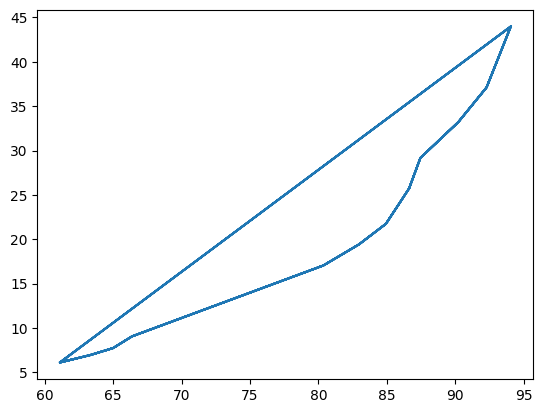

when entailment after filtering: 61.10510274309311%
no entailment after filtering: 6.120921694774651%
6215
34679


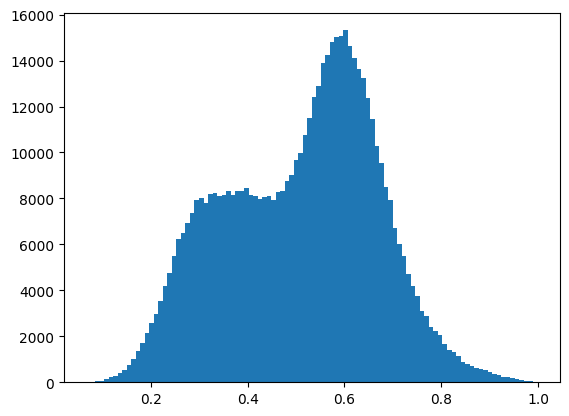

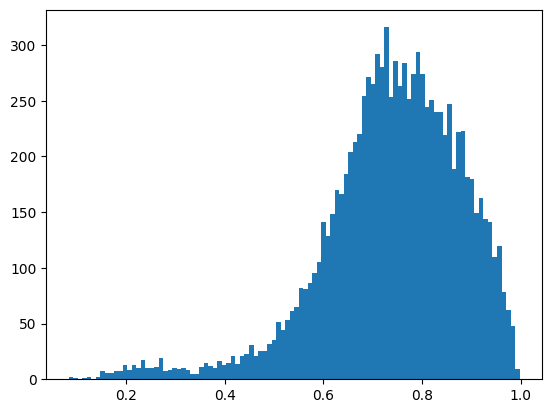

In [ ]:
import matplotlib.pyplot as plt

cosine_similarities_when_entailed = [x["scores"]["sim"] for x in entailments]
cosine_similarities_no_entailment = [x["scores"]["sim"] for x in no_entailments]

logprobs_when_entailed = [x["logprobs"] for x in entailments]
logprobs_no_entailment = [x["logprobs"] for x in no_entailments]


logprobs1_when_entailed = [x[0] for x in logprobs_when_entailed]
logprobs2_when_entailed = [x[1] for x in logprobs_when_entailed]

print(len([x for x in logprobs2_when_entailed if x > -0.3])/len(logprobs2_when_entailed))

# plt.hist(logprobs2_when_entailed, bins=1000)
# plt.show()

logprobs1_no_entailment = [x[0] for x in logprobs_no_entailment]
logprobs2_no_entailment = [x[1] for x in logprobs_no_entailment]

# plt.hist(logprobs2_no_entailment, bins=1000)
# plt.show()
print(len([x for x in logprobs2_no_entailment if x > -0.3])/len(logprobs2_no_entailment))


def filter_entailment(x, threshold=0.5, shorter: int = -10):
    if x["logprobs"][1] > -0.3:
        return True
    if x["scores"]["sim"] < threshold:
        return False
    if x["scores"]["shorter"] < shorter:
        return False
    return True
    
threshold = 0.6
shorter = -10
entailed_filtered = [x for x in entailments if filter_entailment(x, threshold=threshold, shorter=shorter)]
not_entailed_filtered = [x for x in no_entailments if filter_entailment(x, threshold=threshold, shorter=shorter)]


logprob_params = [-0.5, -0.4, -0.3, -0.2, -0.1]
threshold_params = [0.5, 0.6, 0.7]
shorter_params = [-20, -10, -5, 0]

all_percentage_entailed_filtered = []
all_percentage_not_entailed_filtered = []
for logprob in logprob_params:
    for threshold in threshold_params:
        for shorter in shorter_params:
            entailed_filtered = [x for x in entailments if filter_entailment(x, threshold=threshold, shorter=shorter)]
            not_entailed_filtered = [x for x in no_entailments if filter_entailment(x, threshold=threshold, shorter=shorter)]
            percentage_entailed_filtered = len(entailed_filtered)/len(entailments)*100
            percentage_not_entailed_filtered = len(not_entailed_filtered)/len(no_entailments)*100
            if percentage_entailed_filtered - percentage_not_entailed_filtered > 100:
                print(f"logprob: {logprob}, threshold: {threshold}, shorter: {shorter}")
                print(f"percentage_entailed_filtered: {percentage_entailed_filtered}, percentage_not_entailed_filtered: {percentage_not_entailed_filtered}")
            all_percentage_entailed_filtered.append(percentage_entailed_filtered)
            all_percentage_not_entailed_filtered.append(percentage_not_entailed_filtered)
            

plt.plot(all_percentage_entailed_filtered, all_percentage_not_entailed_filtered)
plt.show()

# find the entailed that are filtered out and check investigate what the pairs look like
# entailed_filtered_out = [x for x in entailments if not filter_entailment(x, threshold=threshold, shorter=shorter)]
# for x in entailed_filtered_out:
#     print(x["text"])
#     print(x["text_pair"])
#     print("\n")


print(f"when entailment after filtering: {len(entailed_filtered)/len(entailments)*100}%")
print(f"no entailment after filtering: {len(not_entailed_filtered)/len(no_entailments)*100}%")
print(len(entailed_filtered))
print(len(not_entailed_filtered))
#plot histograms
plt.hist(cosine_similarities_no_entailment, bins=100)
plt.show()
plt.hist(cosine_similarities_when_entailed, bins=100)
plt.show()
# 86.84654300168634%
# 26.27055051504195%

In [ ]:
def visualize_hierarchy(matrix, clusters):
    dot = graphviz.Digraph(comment='My Hierarchical DAG', graph_attr={'rankdir': 'TB'})
    representatives = [c["representative"] for c in clusters]
    for i in range(len(representatives))    :
        dot.node(f'{representatives[i]["atomic_fact"]}', f'{representatives[i]["atomic_fact"]}')
        for j in range(len(representatives)):
            if i == j:
                continue
            elif matrix[i][j] > 0.5:
                rep = representatives[i]
                other_rep = representatives[j]
                dot.edge(f'{other_rep["atomic_fact"]}', f'{rep["atomic_fact"]}', label=f'{matrix[i][j]:.2f} ({matrix[j][i]:.2f})')
    return dot

dot = visualize_hierarchy(matrix, filtered_clusters)

# create png
dot.render('hierarchy', format='png')


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.276702 to fit


'hierarchy.png'

In [ ]:
number_of_clusters_per_query = [len(q["clusters"]) for q in query_clusters]
print("Number of clusters per query: ", number_of_clusters_per_query)
print(sum([x for x in number_of_clusters_per_query]))

Number of clusters per query:  [6, 13, 17, 23, 37, 63, 48, 57, 47, 51, 71, 11, 10, 89, 56, 91, 91, 7, 103, 111, 124, 126, 85, 50, 103, 122, 10, 149, 100, 6, 169, 131, 142, 160, 136, 13, 75, 170, 18, 86, 175, 88, 157, 123, 151, 163, 160, 189, 154, 212, 138, 9, 173, 220, 170, 161, 217, 184, 171, 181, 213, 167, 35, 72, 186, 56, 194, 71, 165, 183, 157, 74, 14, 177, 46, 49, 192, 82, 178, 83, 184, 41, 193, 227, 174, 117, 152, 53, 44, 111, 51, 73, 36, 126, 143, 11, 128, 137, 170, 153, 160, 113, 137, 41, 143, 107, 50, 91, 109, 219, 77, 107, 157, 189, 188, 214, 211, 192, 193, 134, 122, 105, 137, 192, 153, 3, 124, 13, 61, 67, 155, 163, 91, 208, 180, 170, 130, 76, 14, 149, 111, 107, 165, 165, 30, 172, 80, 141, 180, 168, 139, 129, 147, 134, 157, 157, 213, 107, 210, 203, 200, 153, 158, 172, 203, 143, 181, 138, 142, 63, 15, 100, 66, 161, 141, 94, 13, 56, 189, 146, 145, 123, 226, 140, 180, 78, 74, 155, 162, 115, 229, 212, 118, 144, 173, 228, 79, 202, 182, 161, 122, 152, 18, 136, 200, 159, 141, 146, 1

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/1321 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 5.97 GiB. GPU 0 has a total capacity of 94.97 GiB of which 2.66 GiB is free. Including non-PyTorch memory, this process has 92.30 GiB memory in use. Of the allocated memory 85.69 GiB is allocated by PyTorch, and 5.98 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
to_embed = []
for query in query_clusters:
    for cluster in query["clusters"]:
        for atomic_fact in cluster["atomic_facts"]:
            to_embed.append(atomic_fact["atomic_fact"])

results = embedding_model.encode(
    to_embed,
    batch_size=64,          # optional
    show_progress_bar=True, # <-- adds a live tqdm bar
)


counter = 0
for query in query_clusters:
    for i, cluster in enumerate(query["clusters"]):
        for j, atomic_fact in enumerate(cluster["atomic_facts"]):
            atomic_fact["embedding"] = results[counter]
            counter += 1


Batches:   0%|          | 0/1948 [00:00<?, ?it/s]

In [ ]:
import numpy as np
# for each cluster, find the smallest cosine similarity within the cluster
smallest_similarity = 1.0
smallest_cluster = None
identical_facts = 0
similarities_within_cluster = []
for query in query_clusters:
    for cluster in query["clusters"]:
        min_similarity = 1.0
        if len(cluster["atomic_facts"]) < 2:
            continue
        for i, atomic_fact in enumerate(cluster["atomic_facts"]):
            for j, other_atomic_fact in enumerate(cluster["atomic_facts"]):
                if i == j:
                    continue
                if atomic_fact["atomic_fact"] == other_atomic_fact["atomic_fact"]:
                    identical_facts += 1
                similarity = np.dot(atomic_fact["embedding"], other_atomic_fact["embedding"]) / (np.linalg.norm(atomic_fact["embedding"]) * np.linalg.norm(other_atomic_fact["embedding"]))
                similarities_within_cluster.append(similarity)
                if similarity < min_similarity:
                    min_similarity = similarity
                    smallest_cluster = cluster
        if min_similarity < smallest_similarity:
            smallest_similarity = min_similarity
            smallest_cluster = cluster
print(smallest_similarity)
for fact in smallest_cluster["atomic_facts"]:
    print(fact["atomic_fact"])
print()



0.58559436
Lou Briel performed at the Show Time nightspot in 2006.
Lou Briel performed at the "Show Time" nightspot in 2006.



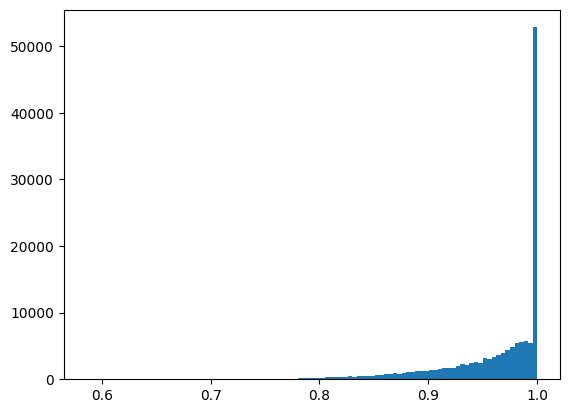

2344
1.6315620954157561
34.06373115420489


In [ ]:
import matplotlib.pyplot as plt
plt.hist(similarities_within_cluster, bins=100)
plt.show()

filtered = [x for x in similarities_within_cluster if x < 0.8]
print(len(filtered))
print(len(filtered)/len(similarities_within_cluster)*100)

percentage_identical_facts = identical_facts/len(similarities_within_cluster)*100
print(percentage_identical_facts)




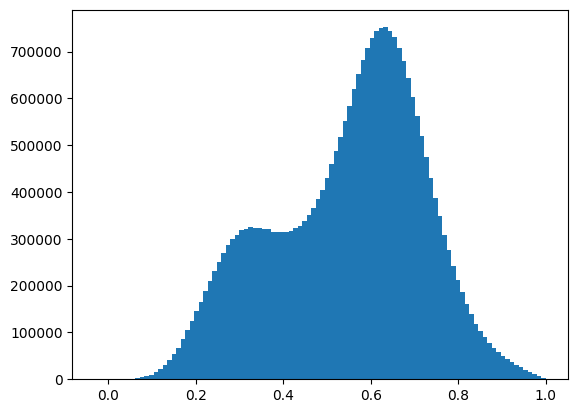

In [ ]:
similarities_outside_cluster = []
for query in query_clusters:
    for cluster in query["clusters"]:
        for atomic_fact in cluster["atomic_facts"]:
            for other_cluster in query["clusters"]:
                if other_cluster == cluster:
                    continue
                for other_atomic_fact in other_cluster["atomic_facts"]:
                    similarity = np.dot(atomic_fact["embedding"], other_atomic_fact["embedding"]) / (np.linalg.norm(atomic_fact["embedding"]) * np.linalg.norm(other_atomic_fact["embedding"]))
                    similarities_outside_cluster.append(similarity)

plt.hist(similarities_outside_cluster, bins=100)
plt.show()


In [ ]:
after_filtering = [x for x in similarities_outside_cluster if x < 0.8]
print(len(after_filtering))
print(len(after_filtering)/len(similarities_outside_cluster)*100)










25709860
95.10630804993644
